<a href="https://colab.research.google.com/github/sonia73b/tech405asst/blob/main/Tech405Asst_3_SONIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Load dataset
data = load_breast_cancer()

# Create dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
# Show first few rows
print(df.head())

# Basic info
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print("Missing values:\n", df.isnull().sum())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

target
0    212
1    357
Name: count, dtype: int64


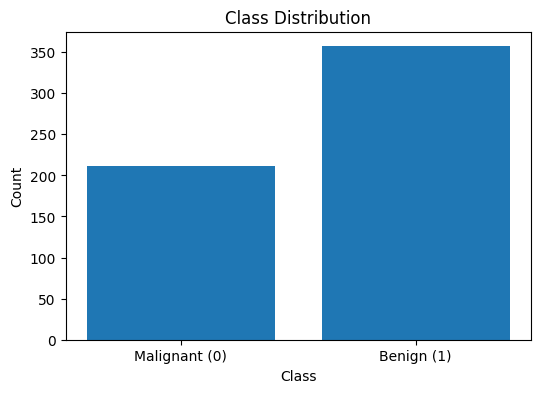

In [ ]:
target_counts = df['target'].value_counts().sort_index()
print(target_counts)

plt.figure(figsize=(6,4))
plt.bar(['Malignant (0)', 'Benign (1)'], target_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xlabel("Class")
plt.show()

In [ ]:
# Correlation with target
correlation_with_target = df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

print("Top correlated features with target:")
print(correlation_with_target.head(10))

# Select top 3 features
top_3_features = correlation_with_target.head(3).index.tolist()
print("Selected top 3 features:", top_3_features)

# New dataframe with selected features
selected_df = df[top_3_features + ['target']]
print(selected_df.head())

Top correlated features with target:
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64
Selected top 3 features: ['worst concave points', 'worst perimeter', 'mean concave points']
   worst concave points  worst perimeter  mean concave points  target
0                0.2654           184.60              0.14710       0
1                0.1860           158.80              0.07017       0
2                0.2430           152.50              0.12790       0
3                0.2575            98.87              0.10520       0
4                0.1625           152.20              0.10430       0


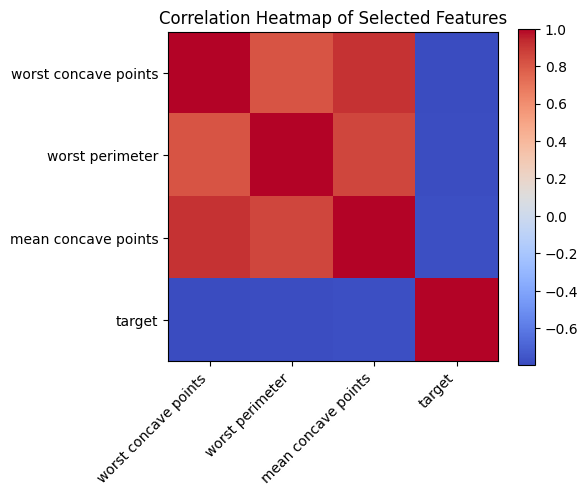

In [ ]:
corr_matrix = selected_df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

In [ ]:
# Split features and target
X = selected_df[top_3_features].values
y = selected_df['target'].values.reshape(-1, 1)

# Normalize input features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 3)
X_test shape: (114, 3)
y_train shape: (455, 1)
y_test shape: (114, 1)


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [ ]:
np.random.seed(42)

input_neurons = 3
hidden_neurons = 3
output_neurons = 1

# Weight matrices
W1 = np.random.uniform(size=(input_neurons, hidden_neurons))
W2 = np.random.uniform(size=(hidden_neurons, output_neurons))

print("Initial W1:\n", W1)
print("Initial W2:\n", W2)

Initial W1:
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]]
Initial W2:
 [[0.70807258]
 [0.02058449]
 [0.96990985]]


In [ ]:
learning_rate = 0.5
epochs = 5000
m = X_train.shape[0]

losses = []

for epoch in range(epochs):
    # -------------------------
    # Forward Pass
    # -------------------------
    hidden_input = np.dot(X_train, W1)
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2)
    predicted_output = sigmoid(final_input)

    # -------------------------
    # Error calculation
    # -------------------------
    error = y_train - predicted_output
    mse = np.mean(np.square(error))
    losses.append(mse)

    # -------------------------
    # Backpropagation
    # -------------------------
    d_predicted_output = error * sigmoid_derivative(predicted_output)

    error_hidden_layer = d_predicted_output.dot(W2.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_output)

    # -------------------------
    # Weight updates
    # -------------------------
    W2 += hidden_output.T.dot(d_predicted_output) * learning_rate / m
    W1 += X_train.T.dot(d_hidden_layer) * learning_rate / m

    # Print progress occasionally
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {mse:.6f}")

Epoch 0, Loss: 0.259884
Epoch 500, Loss: 0.198231
Epoch 1000, Loss: 0.120856
Epoch 1500, Loss: 0.093783
Epoch 2000, Loss: 0.081682
Epoch 2500, Loss: 0.074617
Epoch 3000, Loss: 0.069893
Epoch 3500, Loss: 0.066478
Epoch 4000, Loss: 0.063882
Epoch 4500, Loss: 0.061841


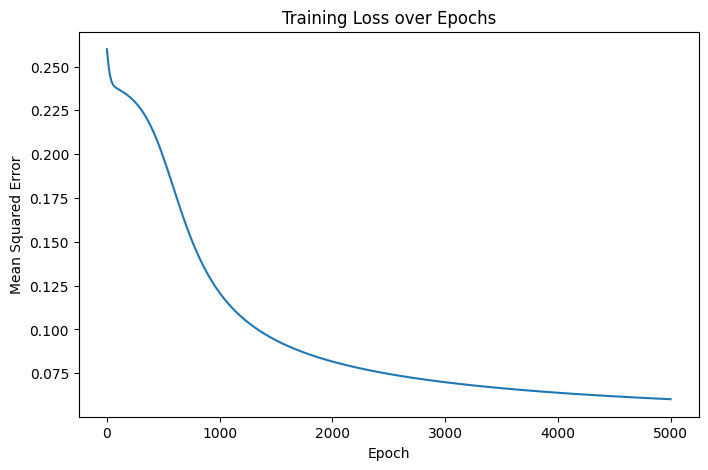

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.show()

In [ ]:
# Forward pass on test data
hidden_input_test = np.dot(X_test, W1)
hidden_output_test = sigmoid(hidden_input_test)

final_input_test = np.dot(hidden_output_test, W2)
predicted_test = sigmoid(final_input_test)

# Convert probabilities to class labels
predicted_classes = (predicted_test >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(predicted_classes == y_test)
print("Test Accuracy:", accuracy)

# Show some predictions
results = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted_Probability': predicted_test.flatten(),
    'Predicted_Class': predicted_classes.flatten()
})

print(results.head(10))

Test Accuracy: 0.9473684210526315
   Actual  Predicted_Probability  Predicted_Class
0       1               0.753404                1
1       0               0.125420                0
2       0               0.241012                0
3       1               0.877737                1
4       1               0.921622                1
5       0               0.042588                0
6       0               0.042373                0
7       0               0.219420                0
8       1               0.392560                0
9       1               0.904890                1


In [ ]:
print("Final W1:\n", W1)
print("Final W2:\n", W2)

Final W1:
 [[-0.74665262  1.24821878 -0.65613087]
 [-1.5771093   1.09066743 -2.0779909 ]
 [-2.07775557  1.82700705 -1.61545732]]
Final W2:
 [[ 7.52105003]
 [-3.80036822]
 [ 7.16134435]]
